In [28]:
import pandas as pd 

In [29]:
DATSET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/refs/heads/main/datasets/dataset.csv"
df = pd.read_csv(DATSET_LOC)
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
df.tag.value_counts()

tag
natural-language-processing    310
computer-vision                285
other                          106
mlops                           63
Name: count, dtype: int64

In [32]:
test_size = 0.2
train_df, val_df = train_test_split(df, stratify=df.tag, test_size=test_size, random_state=100)

In [33]:
train_df.tag.value_counts()

tag
natural-language-processing    248
computer-vision                228
other                           85
mlops                           50
Name: count, dtype: int64

In [34]:
val_df.tag.value_counts() * int((1-test_size) / test_size)

tag
natural-language-processing    248
computer-vision                228
other                           84
mlops                           52
Name: count, dtype: int64

In [35]:
from collections import Counter
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set_theme()
#import warnings; warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS

In [36]:
all_tags = Counter(df.tag)

In [37]:
all_tags.most_common()

[('natural-language-processing', 310),
 ('computer-vision', 285),
 ('other', 106),
 ('mlops', 63)]

/tmp/ipykernel_1538/4213484816.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(tags,rotation = 0, fontsize = 8)


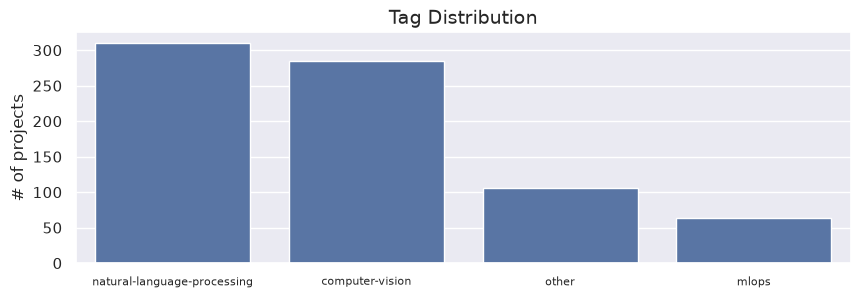

In [38]:
tags, tag_counts = zip(*all_tags.most_common())
plt.figure(figsize=(10,3))
ax = sns.barplot(x=list(tags), y= list(tag_counts))
ax.set_xticklabels(tags,rotation = 0, fontsize = 8)
plt.title("Tag Distribution", fontsize = 14)
plt.ylabel("# of projects", fontsize = 12 )
plt.show()

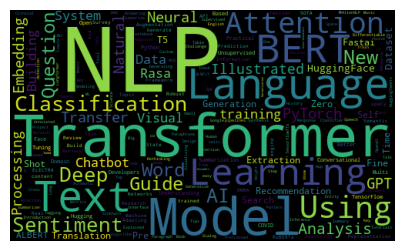

In [39]:
#most frequent tokens for each tag
tag = "natural-language-processing"
plt.figure(figsize=(10,3))
subset = df[df.tag==tag]
text = subset.title.values
cloud = WordCloud(stopwords=STOPWORDS, background_color="black", collocations=False, 
                  width=500, height=300).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

### Preprocessing

In [40]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

In [41]:
# Feature engineering : combining title with description 
df["text"] = df.title + " " + df.description

In [42]:
nltk.download("stopwords")
STOPWORDS = stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/cherian/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [43]:
#Cleaning 
def clean_text(text, stopwords=STOPWORDS):
    """Clean raw text string."""
    
    # 1. Remove URLs FIRST (before punctuation is destroyed)
    text = re.sub(r"http\S+", "", text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove stopwords
    # (Doing this before removing punctuation ensures words like "don't" 
    # can be matched correctly if they are in your stopwords list)
    pattern = re.compile(r'\b(' + r"|".join(stopwords) + r")\b\s*")
    text = pattern.sub('', text)

    # 4. Remove all non-alphanumeric characters (The Bulldozer)
    # (We removed the redundant punctuation spacing step entirely)
    text = re.sub("[^A-Za-z0-9]+", " ", text)
    # if punctuations needded
    #text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing

    # 5. Spacing and filters
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()             # strip white space at the ends

    return text

In [44]:
# Apply to dataframe
original_df = df.copy()
df.text = df.text.apply(clean_text)
print (f"{original_df.text.values[0]}\n{df.text.values[0]}")

Comparison between YOLO and RCNN on real world videos Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.
comparison yolo rcnn real world videos bringing theory experiment cool easily train models colab find results minutes


In [45]:
# DataFrame cleanup
df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # drop unnecessory cols
df = df.dropna(subset=["tag"])  # drop nulls in target variable 
df = df[["text", "tag"]]  # rearrange cols
df.head()

,text,tag
0,comparison yolo rcnn real world videos bringin...,computer-vision
1,show infer tell contextual inference creative ...,computer-vision
2,awesome graph classification collection import...,other
3,awesome monte carlo tree search curated list m...,other
4,attentionwalk pytorch implementation watch ste...,other


In [46]:
# Label to index
tags = train_df.tag.unique().tolist()
num_classes = len(tags)
class_to_index = {tag: i for i, tag in enumerate(tags)}
class_to_index

{'natural-language-processing': 0,
 'mlops': 1,
 'computer-vision': 2,
 'other': 3}

In [47]:
df["tag"] = df["tag"].map(class_to_index)
df.head()

,text,tag
0,comparison yolo rcnn real world videos bringin...,2
1,show infer tell contextual inference creative ...,2
2,awesome graph classification collection import...,3
3,awesome monte carlo tree search curated list m...,3
4,attentionwalk pytorch implementation watch ste...,3


In [48]:
# decode function instead of map so that it can be used in np array or a tensor later
# map() is for pandas df only 
def decode(indices, index_to_class):
    return [index_to_class[index] for index in indices]

In [49]:
index_to_class = {v:k for k, v in class_to_index.items()}
# df.head()["tag"].values extracts a NumPy array, stripping away pandas
decode(df.head()["tag"].values, index_to_class=index_to_class)

['computer-vision', 'computer-vision', 'other', 'other', 'other']

In [50]:
import numpy as np
from transformers import BertTokenizer

In [51]:
# Bert tokenizer
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
# moved out of the tokanize funtion so that hugging Face warning and usage of 
# tokens is not repeated each time function is called   

def tokenize(batch):
    # tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
    encoded_inputs = tokenizer(batch["text"].tolist(), return_tensors="np", padding="longest")
    return dict(ids=encoded_inputs["input_ids"], masks=encoded_inputs["attention_mask"], targets=np.array(batch["tag"]))

In [52]:
# Tokenization
tokenize(df.head(1))

{'ids': array([[  102,  2029,  1778,   609,  6446,  4857,  1332,  2399, 13572,
         19125,  1983,  1954,  6240,  3717,  7434,  1262,   537,   201,
          1040,   545,  4714,   103]]),
 'masks': array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]),
 'targets': array([2])}

In [53]:
def preprocess(df, class_to_index):
    """Preprocess the data."""
    df["text"] = df.title + " " + df.description  # feature engineering
    df["text"] = df.text.apply(clean_text)  # clean text
    df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # clean dataframe
    df = df[["text", "tag"]]  # rearrange columns
    df["tag"] = df["tag"].map(class_to_index)  # label encoding
    outputs = tokenize(df)
    return outputs

In [54]:
# Apply
preprocess(df=train_df, class_to_index=class_to_index)

{'ids': array([[  102,   191, 23495, ...,     0,     0,     0],
        [  102,  4417,  2998, ...,     0,     0,     0],
        [  102,  1066,   896, ...,     0,     0,     0],
        ...,
        [  102,  2567,  1995, ...,     0,     0,     0],
        [  102, 28063,   308, ...,     0,     0,     0],
        [  102,  5239,  1572, ...,     0,     0,     0]], shape=(611, 40)),
 'masks': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]], shape=(611, 40)),
 'targets': array([0, 0, 0, 1, 0, 0, 2, 3, 2, 0, 2, 0, 0, 3, 0, 2, 2, 2, 2, 3, 0, 2,
        2, 0, 3, 2, 3, 2, 0, 0, 0, 2, 0, 2, 1, 3, 3, 0, 0, 3, 2, 3, 0, 0,
        0, 2, 3, 0, 0, 0, 0, 2, 1, 1, 0, 0, 2, 1, 0, 3, 3, 0, 0, 0, 3, 0,
        3, 0, 0, 2, 2, 1, 0, 2, 2, 2, 1, 3, 0, 2, 0, 2, 0, 2, 2, 1, 3, 1,
        0, 3, 2, 0, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2, 2, 3, 2, 0, 2, 0,

In [55]:
import os 
import random
import torch
#from ray.data.preprocessor import Preprocessor

In [58]:
# Utilities 
def set_seeds(seed=100):
    #set seeds for reproducibility"
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed=seed) # pytorch cpu
    
    # if gpu is available 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed=seed)
        torch.cuda.manual_seed_all(seed=seed) #if more than 1 gpu

        #cudnn settings 
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    #eval("setattr(torch.backends.cudnn, 'deterministic', True)")
    #eval("setattr(torch.backends.cudnn, 'benchmark', False)")

In [60]:
import json

In [61]:
#class CustomPreprocessor(Preprocessor): - not using ray for now 
class CustomPreprocessor:
    def __init__(self):
        self.class_to_index = {}
        self.index_to_class = {}

    def _fit(self, ds):
        tags = ds["tag"].unique()
        self.class_to_index = {tag: i for i, tag in enumerate(tags)}
        self.index_to_class = {v: k for k,v in self.class_to_index.items()}

    def _transform_pandas(self,batch):
        return preprocess(batch, class_to_index=self.class_to_index)

    def save(self,filepath):
        #Saves the dictionary to a JSON file
        with open(filepath,"w") as f:
            json.dump({"class_to_index": self.class_to_index}, f)

    def load(self,filepath):
        #loads dic from json file
        with open(filepath,"r") as f:
            data = json.load(f)
            self.class_to_index = data["class_to_index"]
            self.index_to_class = {v: k for k,v in self.class_to_index.items()}